In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
df.describe()

,Count,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Value,Churn_Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2281.916928,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.270398,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [4]:
df.median(numeric_only=True)

Count                  1.000000
Zip_Code           93552.000000
Latitude              36.391777
Longitude           -119.730885
Tenure_Months         29.000000
Monthly_Charges       70.350000
Total_Charges       1397.475000
Churn_Value            0.000000
Churn_Score           61.000000
CLTV                4527.000000
dtype: float64

In [5]:
df.mode().iloc[0]

CustomerID                           0002-ORFBO
Count                                       1.0
Country                           United States
State                                California
City                                Los Angeles
Zip_Code                                90001.0
Lat_Long                 32.555828, -117.040073
Latitude                              32.555828
Longitude                           -121.994813
Gender                                     Male
Senior_Citizen                               No
Partner                                      No
Dependents                                   No
Tenure_Months                               1.0
Phone_Service                               Yes
Multiple_Lines                               No
Internet_Service                    Fiber optic
Online_Security                              No
Online_Backup                                No
Device_Protection                            No
Tech_Support                            

In [6]:
df.var(numeric_only=True)

Count              0.000000e+00
Zip_Code           3.481189e+06
Latitude           6.030573e+00
Longitude          4.656485e+00
Tenure_Months      6.031681e+02
Monthly_Charges    9.054109e+02
Total_Charges      5.131450e+06
Churn_Value        1.949764e-01
Churn_Score        4.633313e+02
CLTV               1.399624e+06
dtype: float64

In [7]:
df.std(numeric_only=True)

Count                 0.000000
Zip_Code           1865.794555
Latitude              2.455723
Longitude             2.157889
Tenure_Months        24.559481
Monthly_Charges      30.090047
Total_Charges      2265.270398
Churn_Value           0.441561
Churn_Score          21.525131
CLTV               1183.057152
dtype: float64

In [8]:
df.skew(numeric_only=True)

Count              0.000000
Zip_Code          -0.251463
Latitude           0.303867
Longitude         -0.040792
Tenure_Months      0.239540
Monthly_Charges   -0.220524
Total_Charges      0.963789
Churn_Value        1.063031
Churn_Score       -0.089840
CLTV              -0.311602
dtype: float64

In [9]:
df.kurt(numeric_only=True)

Count              0.000000
Zip_Code          -1.154043
Latitude          -1.135607
Longitude         -1.136050
Tenure_Months     -1.387372
Monthly_Charges   -1.257260
Total_Charges     -0.226400
Churn_Value       -0.870211
Churn_Score       -1.005679
CLTV              -0.934032
dtype: float64

In [10]:
yes = df[df["Churn_Label"]=="Yes"]["Monthly_Charges"]

no = df[df["Churn_Label"]=="No"]["Monthly_Charges"]

stats.ttest_ind(
    yes,
    no
)

TtestResult(statistic=np.float64(16.536738015936308), pvalue=np.float64(2.7066456068884154e-60), df=np.float64(7041.0))

H0:
Monthly charges are equal.

H1:
Monthly charges are different.

In [11]:
contingency = pd.crosstab(
    df["Contract"],
    df["Churn_Label"]
)

stats.chi2_contingency(contingency)

Chi2ContingencyResult(statistic=np.float64(1184.5965720837926), pvalue=np.float64(5.863038300673391e-258), dof=2, expected_freq=array([[2846.69175067, 1028.30824933],
       [1082.11018032,  390.88981968],
       [1245.198069  ,  449.801931  ]]))

In [12]:
fiber = df[df["Internet_Service"]=="Fiber optic"]["Monthly_Charges"]

dsl = df[df["Internet_Service"]=="DSL"]["Monthly_Charges"]

no_service = df[df["Internet_Service"]=="No"]["Monthly_Charges"]

stats.f_oneway(
    fiber,
    dsl,
    no_service
)

F_onewayResult(statistic=np.float64(16111.646283833998), pvalue=np.float64(0.0))

In [13]:
numeric = df.select_dtypes(include=np.number)

numeric.corr()

,Count,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Value,Churn_Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip_Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.001237,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.010168,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.008977,0.004594,0.004260,0.000485
Tenure_Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.825464,-0.352229,-0.224987,0.396406
Monthly_Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.650864,0.193356,0.133754,0.098693
Total_Charges,NaN,-0.001237,-0.010168,0.008977,0.825464,0.650864,1.000000,-0.199037,-0.123948,0.341723
Churn_Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.199037,1.000000,0.664897,-0.127463
Churn_Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.123948,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,0.341723,-0.127463,-0.079782,1.000000


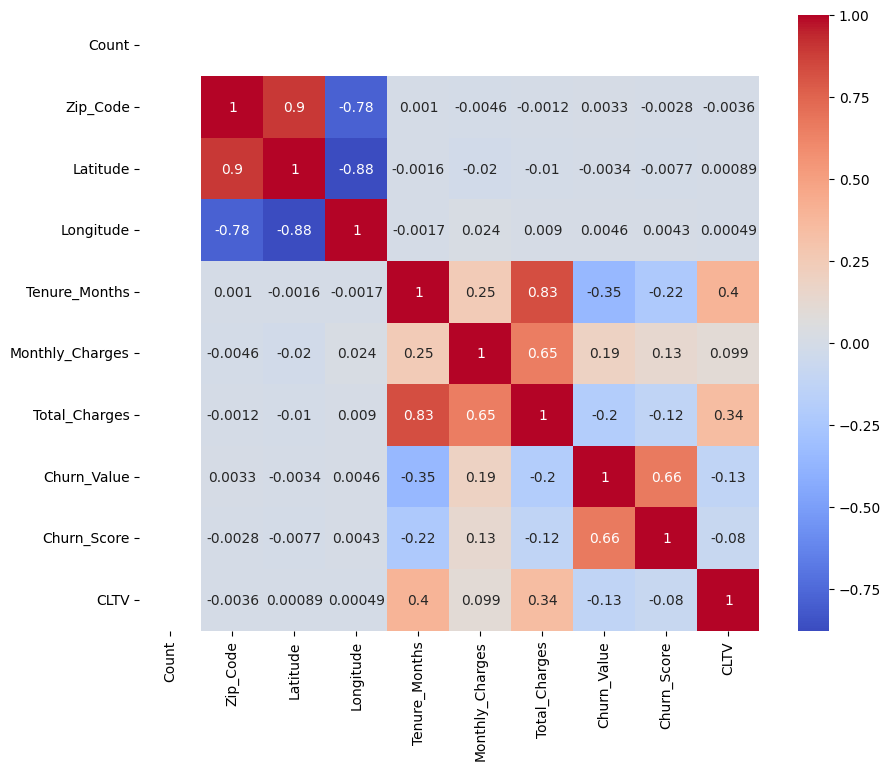

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [16]:
df = pd.read_csv("../data/processed/cleaned_telco.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Churn_Value,Churn_Score,CLTV,Churn_Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [17]:
df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.select_dtypes(include="object").columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

In [18]:
X = df_encoded.drop(
    columns=[
        "Churn_Label",
        "Churn_Value",
        "Churn_Score",
        "Churn_Reason"
    ],
    errors="ignore"
)

y = df_encoded["Churn_Value"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)


In [22]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report\n")

print(classification_report(y_test, lr_pred))

Accuracy : 0.794889992902768
Precision: 0.624633431085044
Recall   : 0.56951871657754
F1 Score : 0.5958041958041959

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.62      0.57      0.60       374

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



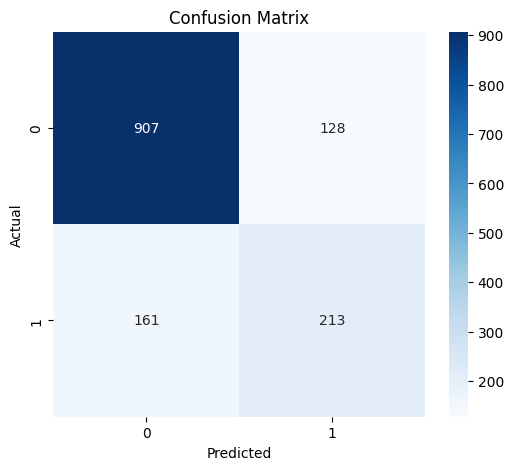

In [23]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

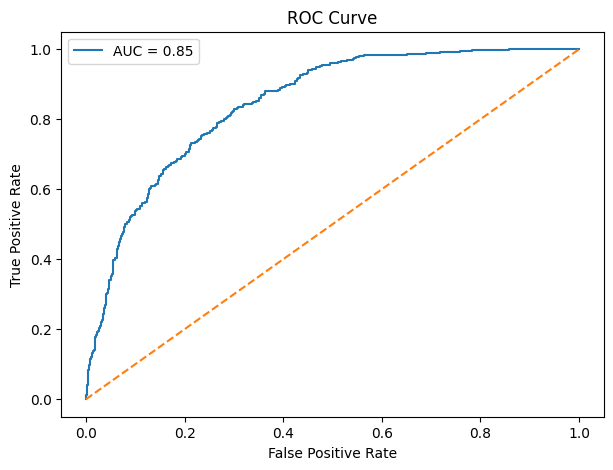

In [24]:
prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

auc = roc_auc_score(y_test, prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [25]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.78708303761533


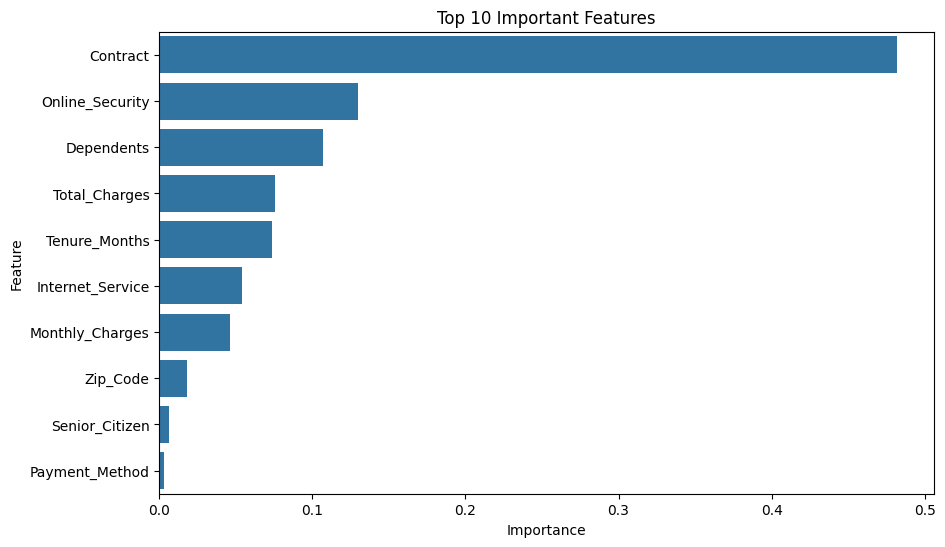

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()